In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [2]:
# 1. Import the dataset
df = pd.read_csv("bodyPerformance.csv")

In [3]:
# 2. Encode categorical variables
df_encoded = df.copy()
le_gender = LabelEncoder()
le_class = LabelEncoder()
df_encoded['gender'] = le_gender.fit_transform(df_encoded['gender'])
df_encoded['class'] = le_class.fit_transform(df_encoded['class'])

In [4]:
# 3. Split features and target
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 4. Define scalers
scalers = {
    "initial": None,
    "standard_scaler": StandardScaler(),
    "min_max_scaler": MinMaxScaler(),
    "max_abs_scaler": MaxAbsScaler()
}

In [6]:
# 5. Train and evaluate SVM for each scaler
results = {}

for key, scaler in scalers.items():
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test

    clf = SVC(kernel="rbf")
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[key] = acc

In [7]:
# 6. Create results table
results_df = pd.DataFrame([results], index=["Accuracy"])
print("SVM Accuracy Comparison Table:\n")
print(results_df.T)

SVM Accuracy Comparison Table:

                 Accuracy
initial          0.604330
standard_scaler  0.699141
min_max_scaler   0.642031
max_abs_scaler   0.655095


In [8]:
# 7. PCA for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(StandardScaler().fit_transform(X))

In [9]:
# 8. Fit SVM with different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
models = {}

for kernel in kernels:
    model = SVC(kernel=kernel, gamma='auto')
    model.fit(X_reduced, y)
    models[kernel] = model

In [10]:
# 9. Create meshgrid for plots
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

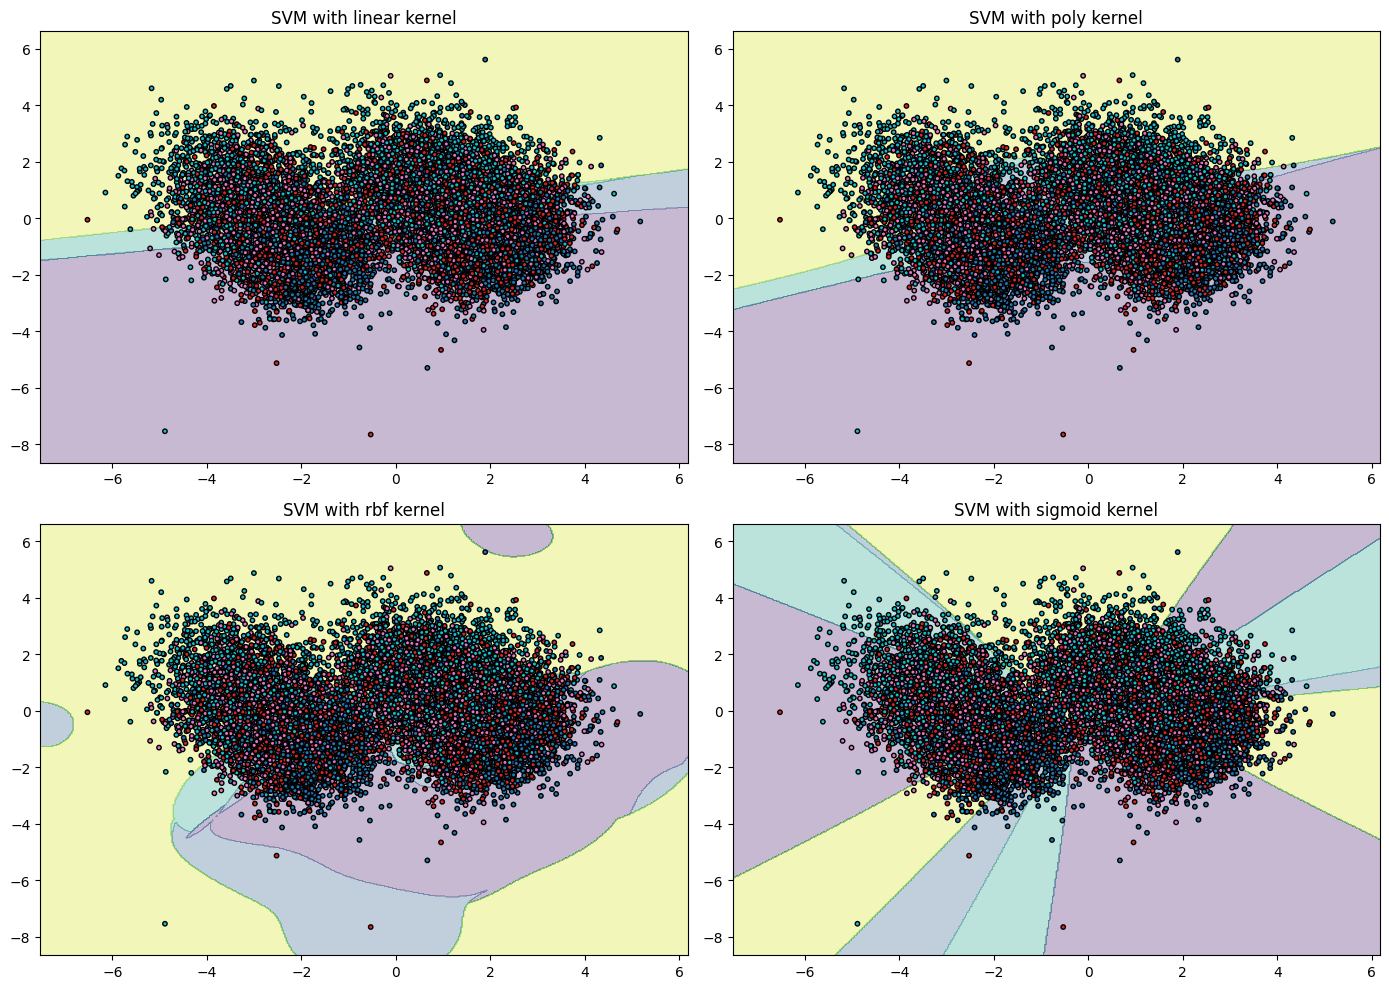

In [ ]:
# 10. Plot decision boundaries
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, kernel in enumerate(kernels):
    Z = models[kernel].predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax = axes[i]
    ax.contourf(xx, yy, Z, alpha=0.3)
    scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, s=10, cmap='tab10', edgecolor='k')
    ax.set_title(f"SVM with {kernel} kernel")

plt.tight_layout()
plt.show()


# 11. My Conclusion

RBF kernel shows a balance of flexibility and separation, making it generally the best default.

Linear kernel is good for speed and interpretability if the data is nearly linearly separable.

Scaling the data before applying SVM is crucial.

The choice of kernel depends on the data distribution and the required model complexity.